In [113]:
import numpy as np
import matplotlib.pyplot as plt
import math as m
import pandas as pd

# Set 8

## 5.5

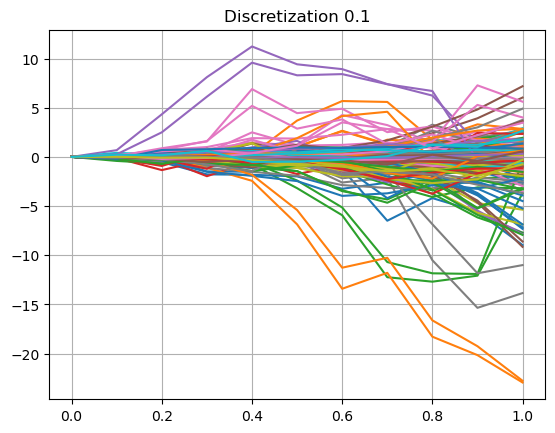

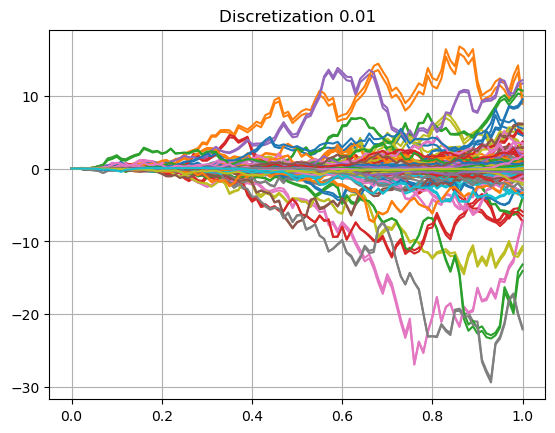

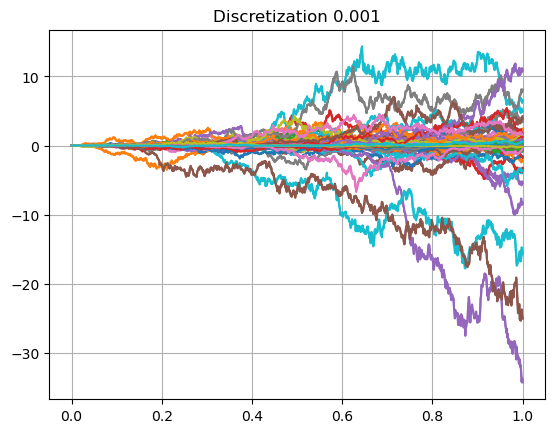

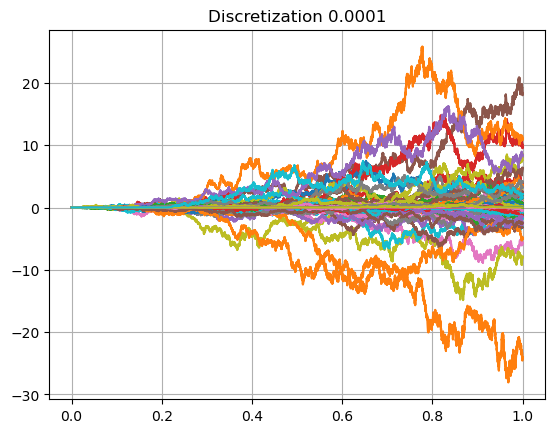

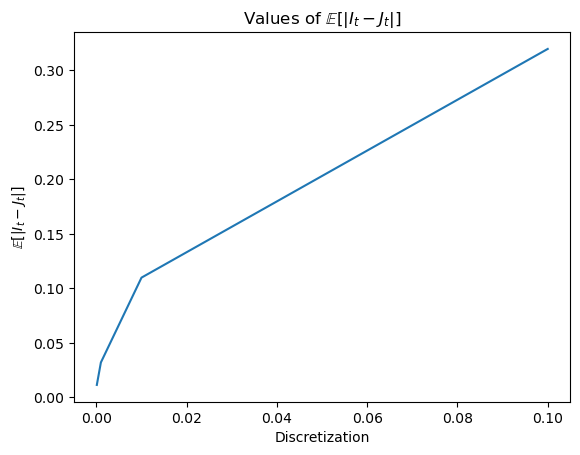

In [114]:
expectation = {}
for diff in [0.1, 0.01, 0.001, 0.0001]:
    x = np.arange(0,1 + diff, diff)
    sample = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(100, len(x) - 1))
    sample = np.append(np.zeros(shape=(100,1)), sample, axis=1)
    BM = np.cumsum(sample, axis=1)
    BM_3 = BM ** 3
    f = np.cumsum(np.append(np.zeros(shape=(100,1)), (BM ** 2)[:,:-1] * np.diff(BM, axis = 1), axis=1), axis=1)
    ito = (3 * f) + (3 * np.cumsum(BM * diff, axis=1))
    
    plt.plot(x,BM_3.T)
    plt.plot(x,ito.T)
    plt.grid(True)
    plt.title(f"Discretization {diff}")
    plt.show()

    expectation[diff] = np.mean(np.abs(BM_3 - ito))

df = pd.DataFrame.from_dict(expectation, orient='index', columns=['Expectation'])
df = df.rename_axis('Discretization', axis=1)


plt.plot(list(expectation.keys()), list(expectation.values()))
plt.title(rf"Values of $\mathbb{{E}}[|I_t - J_t|]$")
plt.xlabel("Discretization")
plt.ylabel(rf"$\mathbb{{E}}[|I_t - J_t|]$")
plt.show()



In [115]:
df

Discretization,Expectation
0.1000,0.319796
0.0100,0.109909
0.0010,0.032035
0.0001,0.011424


## 5.8

### a

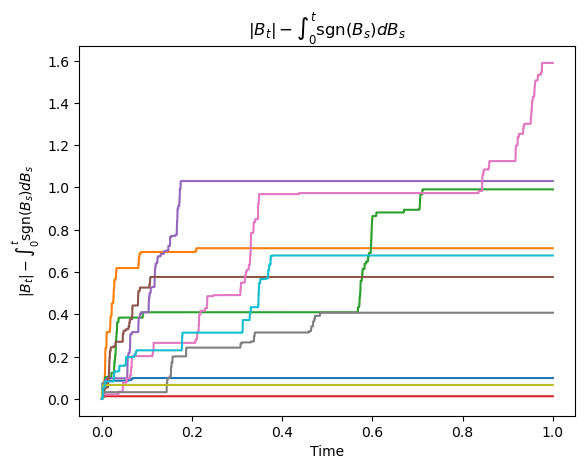

In [116]:
diff = 1/1000000
x = np.arange(0,1 + diff, diff)
sample = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(10, len(x) - 1))
sample = np.append(np.zeros(shape=(10,1)), sample, axis=1)
BM = np.cumsum(sample, axis=1)


def sgn(B_t):
    copy = np.copy(B_t)
    copy[np.where(copy >= 0)] = 1
    copy[np.where(copy < 0)] = -1
    return(copy)

f = sgn(BM)

ito = np.abs(BM) - np.cumsum(np.append(np.zeros(shape=(10,1)) , f[:,:-1] * np.diff(BM, axis=1), axis = 1), axis=1)

plt.plot(x,ito.T)
plt.title(r"$ |B_t| - \int_{0}^{t} \text{sgn}(B_s)dB_s$")
plt.xlabel('Time')
plt.ylabel(r"$ |B_t| - \int_{0}^{t} \text{sgn}(B_s)dB_s$")
plt.show()

### b

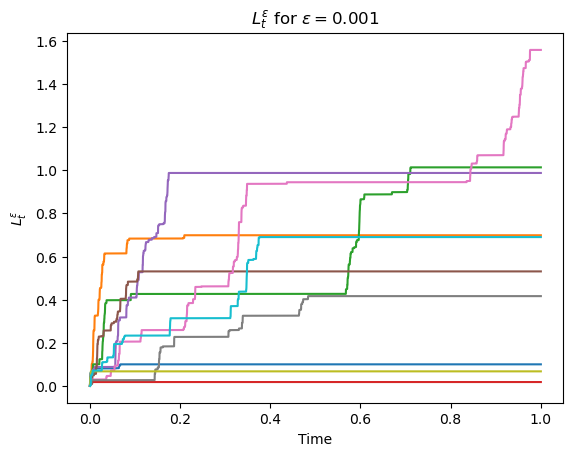

In [117]:
eps = 0.001
L_eps = (1/(2 * eps)) * np.cumsum((np.abs(BM) < eps)/1000000, axis=1)

plt.plot(x,L_eps.T)
plt.title(r"$ L_{t}^{\epsilon}$ for $\epsilon = 0.001$")
plt.xlabel("Time")
plt.ylabel(r"$L_{t}^{\epsilon}$")
plt.show()